# Analyze deconvolved gene expression

In [4]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [39]:
from pipeline.CombinedDeconvolveGeneExpressionRunner import CombinedDeconvolveGeneExpressionRunner

output_directory = 'output/prototype_pipeline_subset/'


In [40]:
from pipeline.expression_analysis import load_deconvolved_gene_expression, \
    plot_volcano_cg1_dg1

deconvolved_genes_F = load_deconvolved_gene_expression(output_directory)

In [41]:
deconvolved_genes_F

,0,1,2,3,4,5,6,7,8,9,...,139,140,141,142,143,144,145,146,147,148
YBR046C,5.829210,5.945749,6.062994,6.180331,6.296598,6.410479,6.522529,6.633668,6.743293,6.851112,...,4.781844,4.747812,4.714312,4.681733,4.651449,4.624699,4.603071,4.588032,4.579088,5.829210
YDR044W,6.031349,6.038888,6.046149,6.052143,6.056485,6.058705,6.058125,6.054319,6.046317,6.033268,...,6.227499,6.216244,6.203926,6.190711,6.176770,6.162275,6.147417,6.132373,6.117277,6.031349
YBR030W,5.344844,5.124501,4.820872,4.502899,4.277388,4.252714,4.373391,4.554241,4.709023,4.743903,...,5.392164,5.392225,5.390277,5.386381,5.380503,5.372635,5.362782,5.350968,5.337371,5.344844
YAL009W,5.385011,5.364466,5.343270,5.322569,5.302743,5.284187,5.268062,5.255354,5.247448,5.245611,...,5.110950,5.109023,5.106661,5.103907,5.100736,5.097120,5.093043,5.088492,5.083528,5.385011
YDL145C,7.982594,7.962864,7.942834,7.923598,7.905528,7.888991,7.875153,7.865037,7.859976,7.861193,...,8.005825,7.980858,7.955779,7.931382,7.908163,7.886403,7.866570,7.849004,7.833697,7.982594
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
YBL003C,6.295432,5.881563,5.422212,4.972719,4.603333,4.385875,4.298413,4.298413,4.349260,4.408086,...,11.817091,11.673818,11.509719,11.323668,11.116723,10.891106,10.647053,10.385169,10.108333,6.295432
YDL153C,5.040835,5.117817,5.200255,5.288087,5.381671,5.481679,5.586462,5.693905,5.802678,5.911353,...,6.995521,6.974168,6.952895,6.932267,6.912729,6.894574,6.878264,6.864120,6.852096,5.040835
YBR050C,2.291286,2.344941,2.397755,2.450063,2.502205,2.554705,2.607029,2.658337,2.708483,2.757184,...,1.869108,1.868670,1.867659,1.866008,1.863612,1.860409,1.856248,1.851001,1.844791,2.291286
YBL016W,7.961452,8.154777,8.383479,8.607303,8.827135,9.041060,9.198848,9.257005,9.161395,8.856354,...,5.872477,5.881330,5.890303,5.899325,5.908094,5.916323,5.923674,5.929832,5.934867,7.961452


Shifting mu0, gamma1, and gamma2, for alpha...


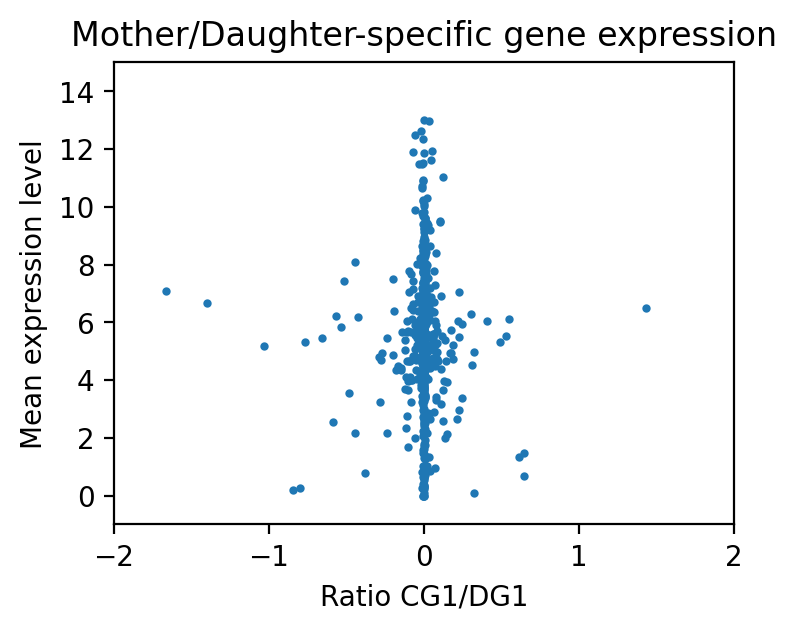

In [43]:
from src.CombinedReplicationDeconvolution import load_config_from_replication_runs
config1, config2 = load_config_from_replication_runs(output_directory, 4, mode='expression')

cg1_dg1_data = plot_volcano_cg1_dg1(deconvolved_genes_F, config1)

In [46]:
from src.geneset import get_deconvolved_geneset

genes = get_deconvolved_geneset()

genes[['gene']].join(cg1_dg1_data[cg1_dg1_data['max_ratio'] < -1], how='inner')


,gene,avg_occ,max_ratio
YBL035C,POL12,5.187393,-1.041075
YBR054W,YRO2,7.078820,-1.662995
YBR071W,YBR071W,6.674961,-1.401426
